# StreamFlow+ Customer Churn Analysis

## 1. Introduction

StreamFlow+ is a subscription-based digital streaming platform that offers Basic, Premium, and Family plans. The company has recently observed an increase in customer churn, especially among users with low engagement, support issues, and payment failures.

This project simulates a real-world data science workflow where a churn problem is approached from a business and analytical perspective. Instead of directly building a machine learning model, the project begins by understanding the business problem, creating a simplified analytics dataset, and performing exploratory data analysis to identify churn patterns.

The goal of this notebook is to analyse customer behaviour and identify the main factors associated with churn.

## 2. Problem Statement

Customer churn is one of the major challenges for subscription-based businesses because losing existing customers directly reduces recurring revenue. StreamFlow+ wants to understand why customers are leaving and which customer behaviours indicate a high risk of churn.

The business objective is to identify patterns that separate churned customers from active customers. These insights can later be used to build a churn prediction model and design targeted retention strategies.

In this project, churn is represented using the `churn_flag` column:

- `churn_flag = 1` means the customer has churned
- `churn_flag = 0` means the customer is still active

## 3. Dataset Description

The dataset used in this project was created from a simulated company database. It represents an analytics-ready table that contains customer subscription, engagement, support, payment, and revenue information.

Each row represents one customer.

## 4. Feature Description

| Feature | Description |
|---|---|
| customer_id | Unique identifier for each customer |
| plan_type | Subscription plan of the customer: Basic, Premium, or Family |
| tenure_days | Number of days the customer has been subscribed |
| watch_hours_30d | Total number of hours watched in the last 30 days |
| login_count_30d | Number of times the customer logged in during the last 30 days |
| days_since_last_login | Number of days since the customer last logged in |
| support_ticket_count | Number of customer support tickets raised by the customer |
| payment_failure_count | Number of failed payment attempts |
| monthly_revenue | Monthly revenue generated by the customer |
| churn_flag | Target variable showing whether the customer churned or not |



In [2]:
!pip install -q seaborn

In [3]:
# import necessory liberaries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("../data/churn_analytics_data.csv")

Perform basic EDA to understand the structure of data

In [5]:
df.head()

,customer_id,plan_type,tenure_days,watch_hours_30d,login_count_30d,days_since_last_login,support_ticket_count,payment_failure_count,monthly_revenue,churn_flag
0,1,Premium,540,85.5,42,1,0,0,20,0
1,2,Premium,480,72.0,38,2,1,0,20,0
2,3,Family,720,95.0,50,1,0,0,30,0
3,4,Basic,60,5.0,4,20,4,2,10,1
4,5,Basic,45,2.5,3,25,5,3,10,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            20 non-null     int64  
 1   plan_type              20 non-null     str    
 2   tenure_days            20 non-null     int64  
 3   watch_hours_30d        20 non-null     float64
 4   login_count_30d        20 non-null     int64  
 5   days_since_last_login  20 non-null     int64  
 6   support_ticket_count   20 non-null     int64  
 7   payment_failure_count  20 non-null     int64  
 8   monthly_revenue        20 non-null     int64  
 9   churn_flag             20 non-null     int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 1.7 KB


the data consist of 9 numeric data type features and 1 object datatype feature.


there are a total of 20 entries

In [7]:
df.describe().T[1:]

,count,mean,std,min,25%,50%,75%,max
tenure_days,20.0,303.750,242.345311,25.0,67.50,325.0,505.000,720.0
watch_hours_30d,20.0,46.275,38.708246,0.5,5.75,60.0,82.875,95.0
login_count_30d,20.0,24.050,18.748965,1.0,4.75,26.5,40.500,50.0
days_since_last_login,20.0,10.250,10.987433,1.0,2.00,3.5,20.500,30.0
support_ticket_count,20.0,1.900,2.149663,0.0,0.00,1.0,4.000,6.0
payment_failure_count,20.0,0.850,1.225819,0.0,0.00,0.0,2.000,4.0
monthly_revenue,20.0,19.000,7.880689,10.0,10.00,20.0,22.500,30.0
churn_flag,20.0,0.350,0.489360,0.0,0.00,0.0,1.000,1.0


there's a bit of variability between features so we will normalize then to bring them to simila4r scale.

In [8]:
df.duplicated().sum()

np.int64(0)

there are no duplicates

In [9]:
df.isna().sum()

customer_id              0
plan_type                0
tenure_days              0
watch_hours_30d          0
login_count_30d          0
days_since_last_login    0
support_ticket_count     0
payment_failure_count    0
monthly_revenue          0
churn_flag               0
dtype: int64

there are no null values

In [10]:
df.nunique()

customer_id              20
plan_type                 3
tenure_days              20
watch_hours_30d          20
login_count_30d          19
days_since_last_login    13
support_ticket_count      7
payment_failure_count     5
monthly_revenue           3
churn_flag                2
dtype: int64

there are 3 features with all unique values and a feature with 19 unique values, out of this only the customer_id feature is primary others feature's define some meaning to them. so we will drop that column. 

## Univarient analysis

In [11]:
analyse_df=df.iloc[:,1:]
analyse_df

,plan_type,tenure_days,watch_hours_30d,login_count_30d,days_since_last_login,support_ticket_count,payment_failure_count,monthly_revenue,churn_flag
0,Premium,540,85.5,42,1,0,0,20,0
1,Premium,480,72.0,38,2,1,0,20,0
2,Family,720,95.0,50,1,0,0,30,0
3,Basic,60,5.0,4,20,4,2,10,1
4,Basic,45,2.5,3,25,5,3,10,1
5,Premium,350,65.0,28,3,1,0,20,0
6,Family,600,88.0,45,2,0,0,30,0
7,Basic,120,12.0,10,8,2,1,10,0
8,Basic,35,1.0,2,28,6,2,10,1
9,Premium,400,70.0,35,2,0,0,20,0


In [12]:
cat_columns=analyse_df.select_dtypes(include='object').columns
num_columns=analyse_df.select_dtypes(exclude='object').columns

C:\Users\tangw\AppData\Local\Temp\ipykernel_15276\2341675048.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_columns=analyse_df.select_dtypes(include='object').columns


In [13]:
print(cat_columns)
print(num_columns)

Index(['plan_type'], dtype='str')
Index(['tenure_days', 'watch_hours_30d', 'login_count_30d',
       'days_since_last_login', 'support_ticket_count',
       'payment_failure_count', 'monthly_revenue', 'churn_flag'],
      dtype='str')


<Axes: xlabel='plan_type'>

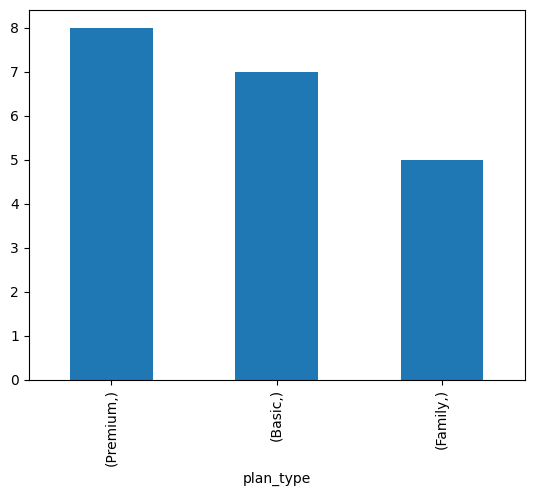

In [14]:
analyse_df[cat_columns].value_counts().plot(kind='bar')

<Axes: >

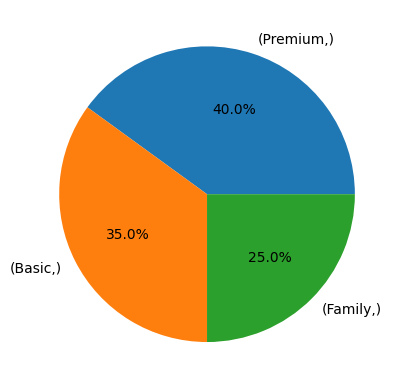

In [22]:
analyse_df[cat_columns].value_counts().plot(kind='pie', autopct='%1.1f%%')

All of them shares almost equal proportion

each plan consist of fare share of users, no plan type is dominating the field.

In [15]:
num_columns.shape

(8,)

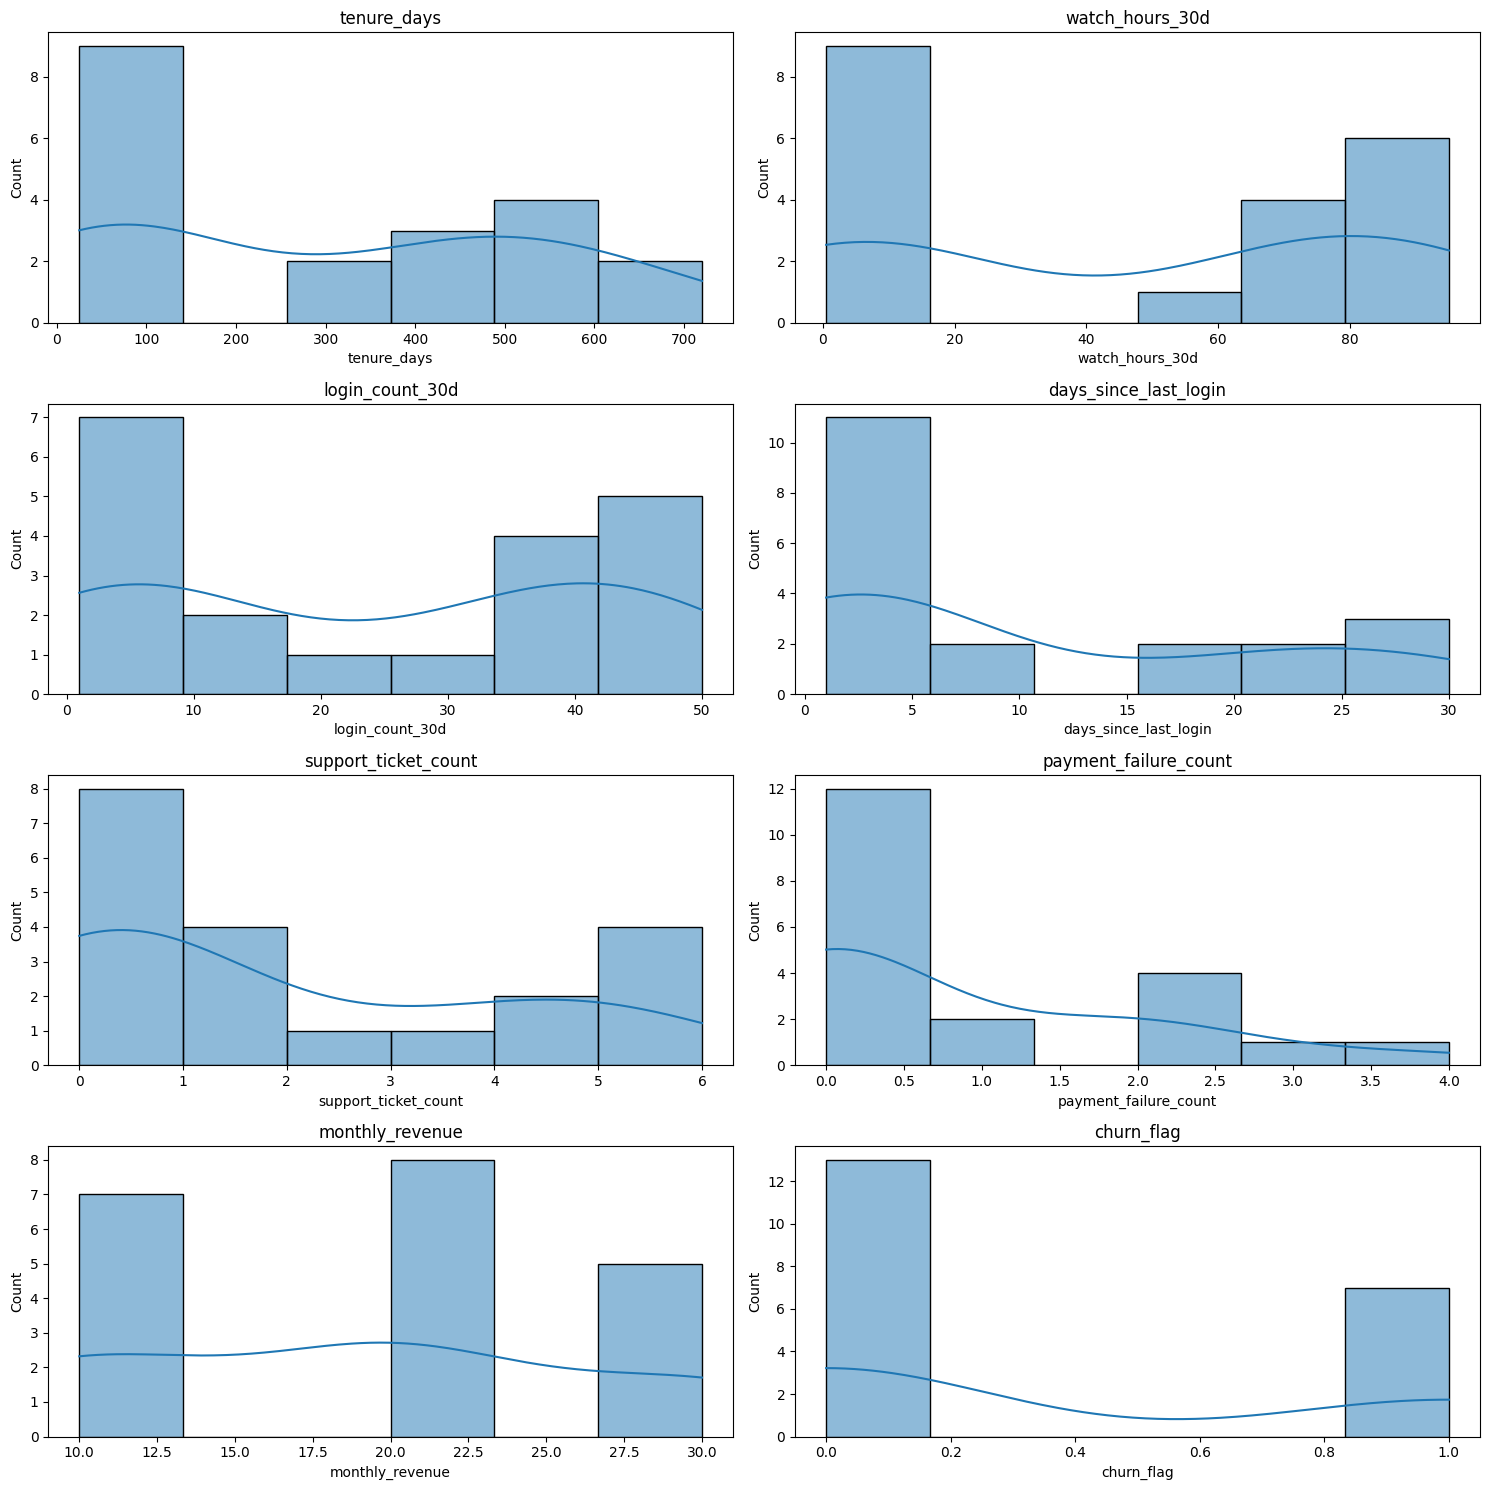

In [16]:
fig, axes = plt.subplots(4, 2, figsize=(15, 15))

for i, column in enumerate(num_columns):
    row = i // 2
    col = i % 2
    sns.histplot(analyse_df[column], ax=axes[row, col], kde=True)
    axes[row, col].set_title(column)

plt.tight_layout()
plt.show()

* **tenure_days:** Customer tenure is widely distributed, with both new and long-term subscribers present in the dataset. we can convert it into 3 categories.
* **watch_hours_30d:** Customer engagement is polarized, with users tending to either watch very little content or consume content heavily. 
* **login_count_30d:** Login activity varies considerably, indicating a mix of highly active and infrequent platform users.
* **days_since_last_login:** Most customers logged in recently, while a smaller group has been inactive for extended periods.
* **support_ticket_count:** The majority of customers raise few or no support tickets, with only a handful requiring frequent assistance.
* **payment_failure_count:** Most customers experience no payment issues, while payment failures are concentrated among a small subset of users.
* **monthly_revenue:** Revenue is clustered around the three subscription tiers ($10, $20, and $30), reflecting the available plan options.
* **churn_flag:** The dataset contains more retained customers than churned customers, with approximately 35% of users having churned.

sincce the sample size is small no need for skew, kurt, and outlier's

## bivarient analysis

In [19]:
num_columns

Index(['tenure_days', 'watch_hours_30d', 'login_count_30d',
       'days_since_last_login', 'support_ticket_count',
       'payment_failure_count', 'monthly_revenue', 'churn_flag'],
      dtype='str')

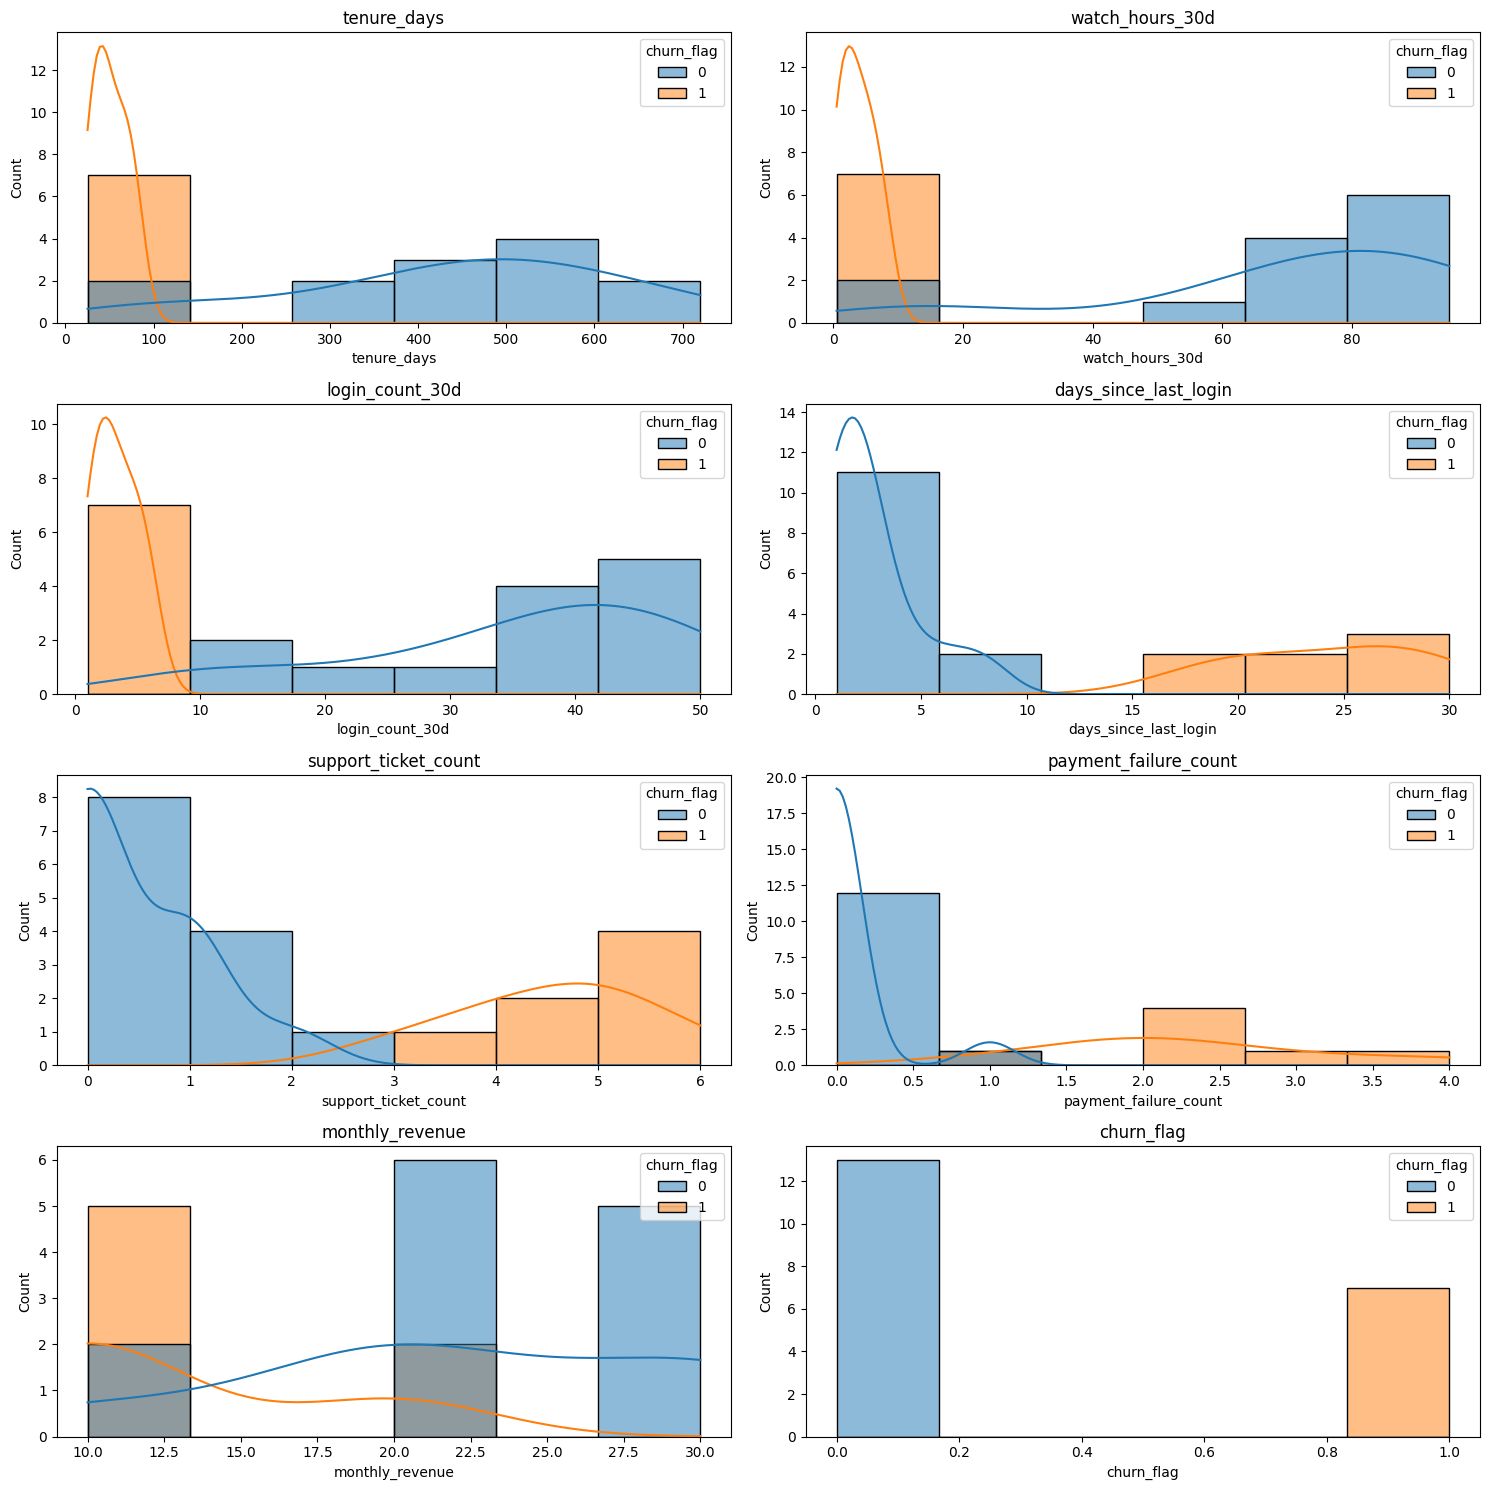

In [21]:
fig, axes = plt.subplots(4, 2, figsize=(15, 15))

for i, column in enumerate(num_columns):
    row = i // 2
    col = i % 2
    sns.histplot(data=analyse_df, x=column, hue='churn_flag', ax=axes[row, col], kde=True)
    axes[row, col].set_title(column)

plt.tight_layout()
plt.show()

* **tenure_days:** New customers appear significantly more likely to churn, while long-term customers show strong retention.
* **watch_hours_30d:** Reduced platform engagement is strongly associated with churn.
* **login_count_30d:** Frequent platform usage is associated with customer retention.
* **days_since_last_login:** Inactivity is one of the clearest warning signs of future churn.
* **support_ticket_count:** Customers who experience more problems are considerably more likely to leave the platform.
* **payment_failure_count:** Billing issues appear to be an important driver of customer churn.
* **monthly_revenue:** Customers on lower-priced plans may be more price-sensitive and more likely to churn.

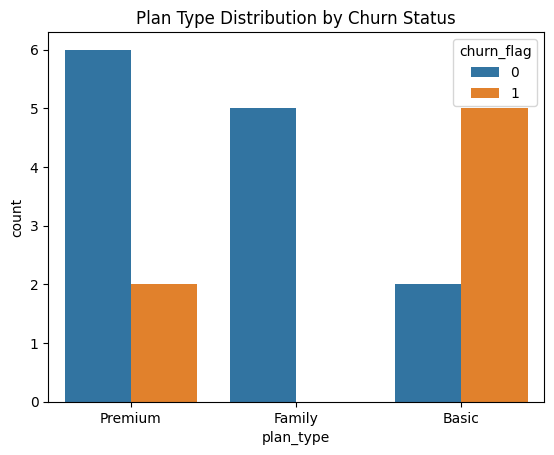

In [31]:
sns.countplot(
    data=analyse_df,
    x='plan_type',
    hue='churn_flag'
)

plt.title('Plan Type Distribution by Churn Status')
plt.show()